# Options Pricing: Black-Scholes and Monte Carlo Methods

This notebook explores the mathematics and implementation of options pricing, covering:
- The Black-Scholes analytical formula
- Monte Carlo simulation for option valuation
- The Greeks: Delta, Gamma, Theta, Vega, Rho
- Comparison of analytical vs simulation approaches

**Key Concepts:**
- Risk-neutral pricing
- Geometric Brownian motion
- No-arbitrage principle

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11

## 1. The Black-Scholes Model

The Black-Scholes formula prices European options under these assumptions:
- Stock price follows geometric Brownian motion: $dS = \mu S dt + \sigma S dW$
- No dividends during option life
- Risk-free rate $r$ is constant
- No transaction costs or taxes
- Continuous trading possible

### Black-Scholes Formula

For a **call option**:
$$C = S_0 N(d_1) - K e^{-rT} N(d_2)$$

For a **put option**:
$$P = K e^{-rT} N(-d_2) - S_0 N(-d_1)$$

Where:
$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}$$
$$d_2 = d_1 - \sigma\sqrt{T}$$

In [2]:
def black_scholes(S, K, T, r, sigma, option_type='call'):
    """
    Calculate Black-Scholes option price.
    
    Parameters:
    -----------
    S : float - Current stock price
    K : float - Strike price
    T : float - Time to expiration (years)
    r : float - Risk-free rate
    sigma : float - Volatility
    option_type : str - 'call' or 'put'
    
    Returns:
    --------
    float - Option price
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    
    return price

# Example calculation
S0 = 100      # Current stock price
K = 100       # Strike price (at-the-money)
T = 1         # 1 year to expiration
r = 0.05      # 5% risk-free rate
sigma = 0.2   # 20% volatility

call_price = black_scholes(S0, K, T, r, sigma, 'call')
put_price = black_scholes(S0, K, T, r, sigma, 'put')

print("Black-Scholes Option Prices")
print("=" * 40)
print(f"Stock Price (S):      ${S0:.2f}")
print(f"Strike Price (K):     ${K:.2f}")
print(f"Time to Expiry (T):   {T} year")
print(f"Risk-free Rate (r):   {r*100:.1f}%")
print(f"Volatility (sigma):     {sigma*100:.1f}%")
print("-" * 40)
print(f"Call Option Price:    ${call_price:.4f}")
print(f"Put Option Price:     ${put_price:.4f}")

# Verify put-call parity: C - P = S - K*e^(-rT)
parity_diff = call_price - put_price
parity_check = S0 - K * np.exp(-r * T)
print(f"\nPut-Call Parity Check:")
print(f"C - P = {parity_diff:.4f}")
print(f"S - Ke^(-rT) = {parity_check:.4f}")

Black-Scholes Option Prices
Stock Price (S):      $100.00
Strike Price (K):     $100.00
Time to Expiry (T):   1 year
Risk-free Rate (r):   5.0%
Volatility (sigma):     20.0%
----------------------------------------
Call Option Price:    $10.4506
Put Option Price:     $5.5735

Put-Call Parity Check:
C - P = 4.8771
S - Ke^(-rT) = 4.8771


## 2. Visualizing Option Prices

Let's see how option prices change with the underlying stock price and time to expiration.

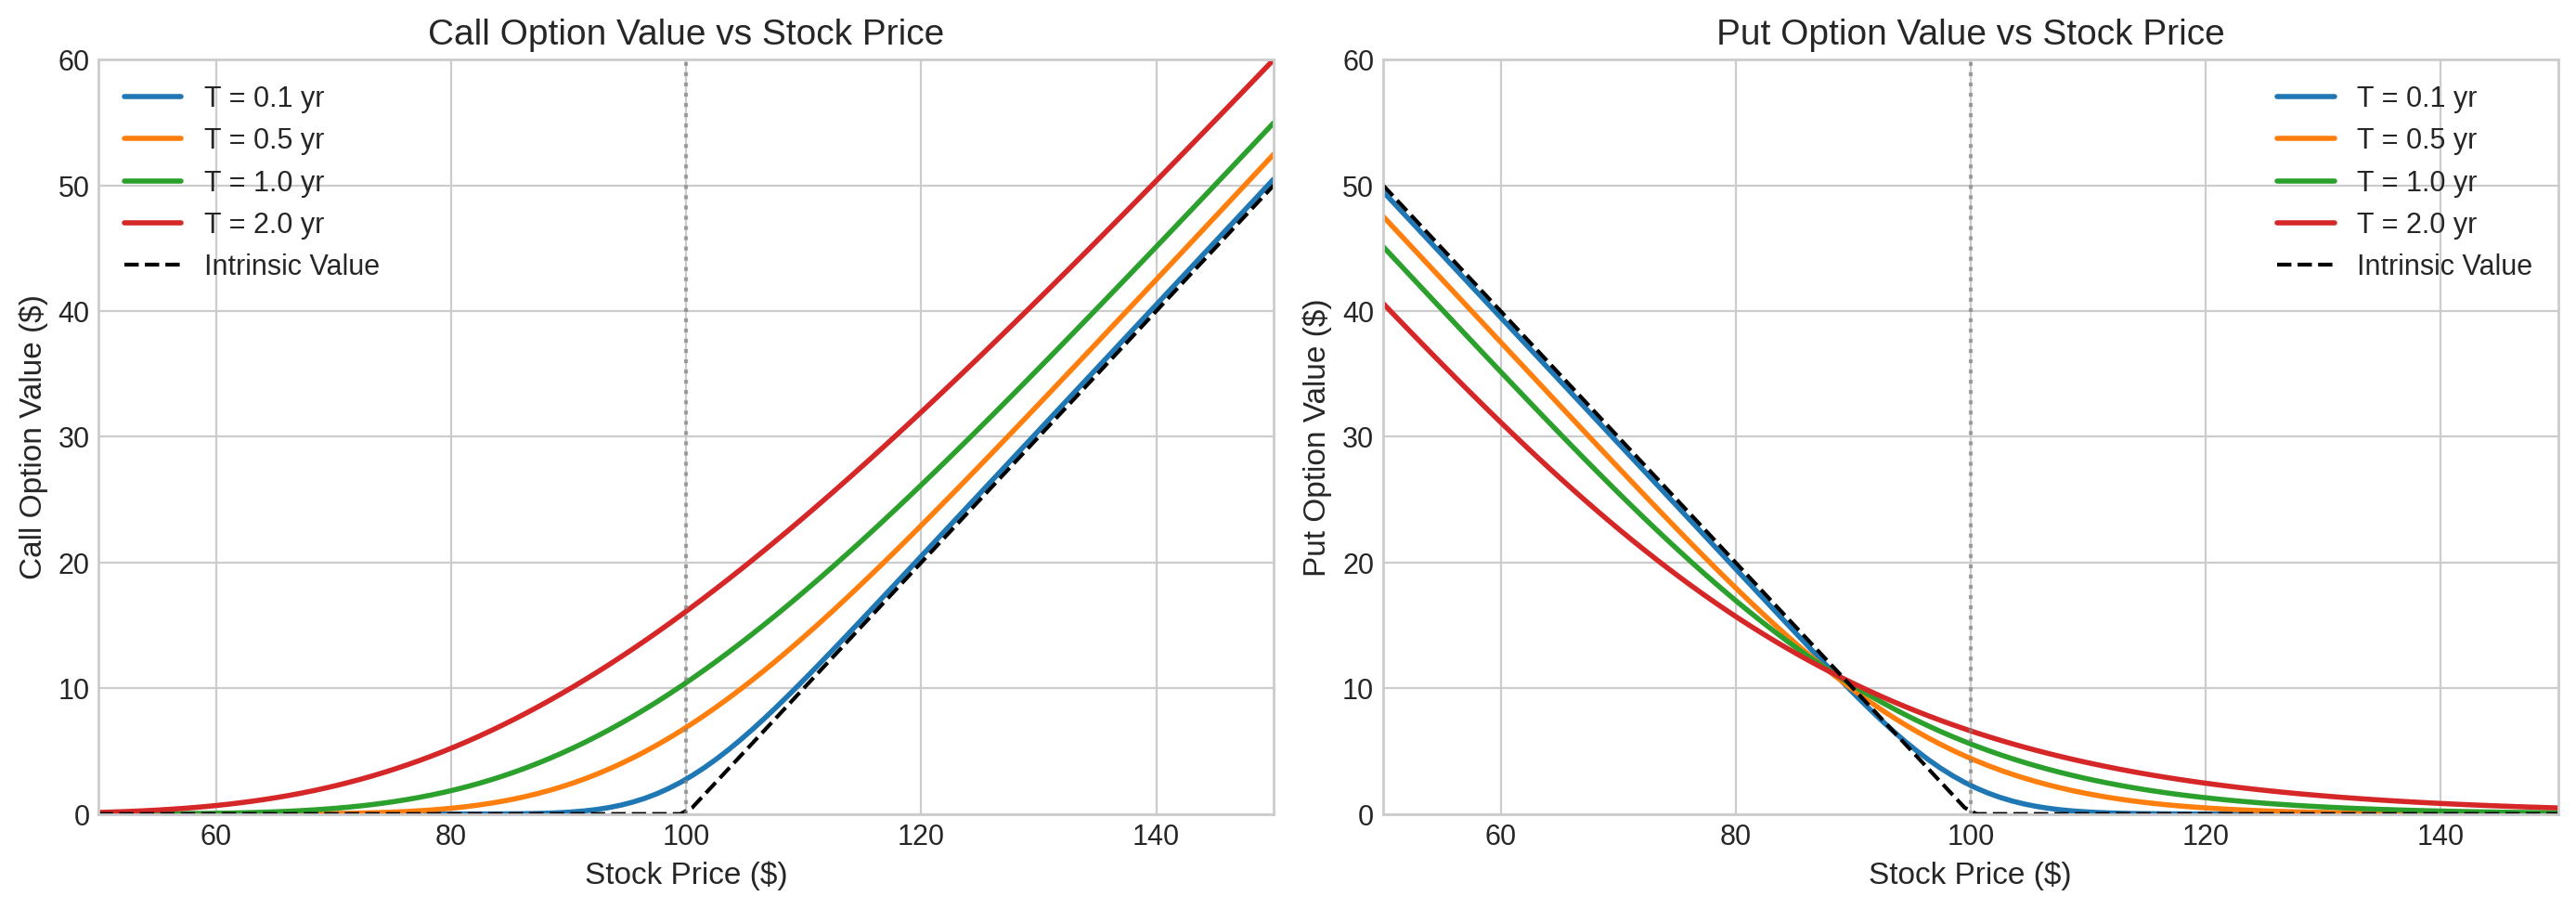

Plot saved: options_pricing_value_curves.png


In [3]:
# Option prices vs stock price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stock_prices = np.linspace(50, 150, 100)
K = 100

# Call options at different times to expiry
ax1 = axes[0]
for T in [0.1, 0.5, 1.0, 2.0]:
    calls = [black_scholes(S, K, T, r, sigma, 'call') for S in stock_prices]
    ax1.plot(stock_prices, calls, label=f'T = {T} yr', linewidth=2)

# Intrinsic value
intrinsic = np.maximum(stock_prices - K, 0)
ax1.plot(stock_prices, intrinsic, 'k--', label='Intrinsic Value', linewidth=1.5)

ax1.axvline(x=K, color='gray', linestyle=':', alpha=0.7)
ax1.set_xlabel('Stock Price ($)', fontsize=12)
ax1.set_ylabel('Call Option Value ($)', fontsize=12)
ax1.set_title('Call Option Value vs Stock Price', fontsize=14)
ax1.legend()
ax1.set_xlim(50, 150)
ax1.set_ylim(0, 60)

# Put options at different times to expiry
ax2 = axes[1]
for T in [0.1, 0.5, 1.0, 2.0]:
    puts = [black_scholes(S, K, T, r, sigma, 'put') for S in stock_prices]
    ax2.plot(stock_prices, puts, label=f'T = {T} yr', linewidth=2)

# Intrinsic value for put
intrinsic_put = np.maximum(K - stock_prices, 0)
ax2.plot(stock_prices, intrinsic_put, 'k--', label='Intrinsic Value', linewidth=1.5)

ax2.axvline(x=K, color='gray', linestyle=':', alpha=0.7)
ax2.set_xlabel('Stock Price ($)', fontsize=12)
ax2.set_ylabel('Put Option Value ($)', fontsize=12)
ax2.set_title('Put Option Value vs Stock Price', fontsize=14)
ax2.legend()
ax2.set_xlim(50, 150)
ax2.set_ylim(0, 60)

plt.tight_layout()
plt.savefig('options_pricing_value_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved: options_pricing_value_curves.png")

## 3. The Greeks

The Greeks measure option price sensitivity to various factors:

| Greek | Symbol | Measures Sensitivity To | Formula (Call) |
|-------|--------|------------------------|----------------|
| Delta | $\Delta$ | Stock price | $N(d_1)$ |
| Gamma | $\Gamma$ | Delta (2nd derivative) | $\frac{N'(d_1)}{S\sigma\sqrt{T}}$ |
| Theta | $\Theta$ | Time decay | Complex |
| Vega | $\mathcal{V}$ | Volatility | $S N'(d_1) \sqrt{T}$ |
| Rho | $\rho$ | Interest rate | $KT e^{-rT} N(d_2)$ |

In [4]:
def calculate_greeks(S, K, T, r, sigma, option_type='call'):
    """
    Calculate all Greeks for an option.
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # Standard normal PDF at d1
    n_d1 = norm.pdf(d1)
    
    if option_type == 'call':
        delta = norm.cdf(d1)
        theta = (-S * n_d1 * sigma / (2 * np.sqrt(T)) 
                 - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
        rho = K * T * np.exp(-r * T) * norm.cdf(d2) / 100
    else:
        delta = norm.cdf(d1) - 1
        theta = (-S * n_d1 * sigma / (2 * np.sqrt(T)) 
                 + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365
        rho = -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100
    
    # Gamma and Vega are the same for calls and puts
    gamma = n_d1 / (S * sigma * np.sqrt(T))
    vega = S * n_d1 * np.sqrt(T) / 100  # Per 1% change in vol
    
    return {
        'delta': delta,
        'gamma': gamma,
        'theta': theta,
        'vega': vega,
        'rho': rho
    }

# Calculate Greeks for our example
call_greeks = calculate_greeks(S0, K, T, r, sigma, 'call')
put_greeks = calculate_greeks(S0, K, T, r, sigma, 'put')

print("The Greeks for ATM Options")
print("=" * 50)
print(f"{'Greek':<12} {'Call':<15} {'Put':<15}")
print("-" * 50)
print(f"{'Delta':<12} {call_greeks['delta']:<15.4f} {put_greeks['delta']:<15.4f}")
print(f"{'Gamma':<12} {call_greeks['gamma']:<15.4f} {put_greeks['gamma']:<15.4f}")
print(f"{'Theta':<12} {call_greeks['theta']:<15.4f} {put_greeks['theta']:<15.4f}")
print(f"{'Vega':<12} {call_greeks['vega']:<15.4f} {put_greeks['vega']:<15.4f}")
print(f"{'Rho':<12} {call_greeks['rho']:<15.4f} {put_greeks['rho']:<15.4f}")
print("\nNote: Theta per day, Vega/Rho per 1% change")

The Greeks for ATM Options
Greek        Call            Put            
--------------------------------------------------
Delta        0.6897          -0.3103        
Gamma        0.0125          0.0125         
Theta        -0.0141         -0.0017        
Vega         0.4991          0.4991         
Rho          1.0568          -0.7528        

Note: Theta per day, Vega/Rho per 1% change


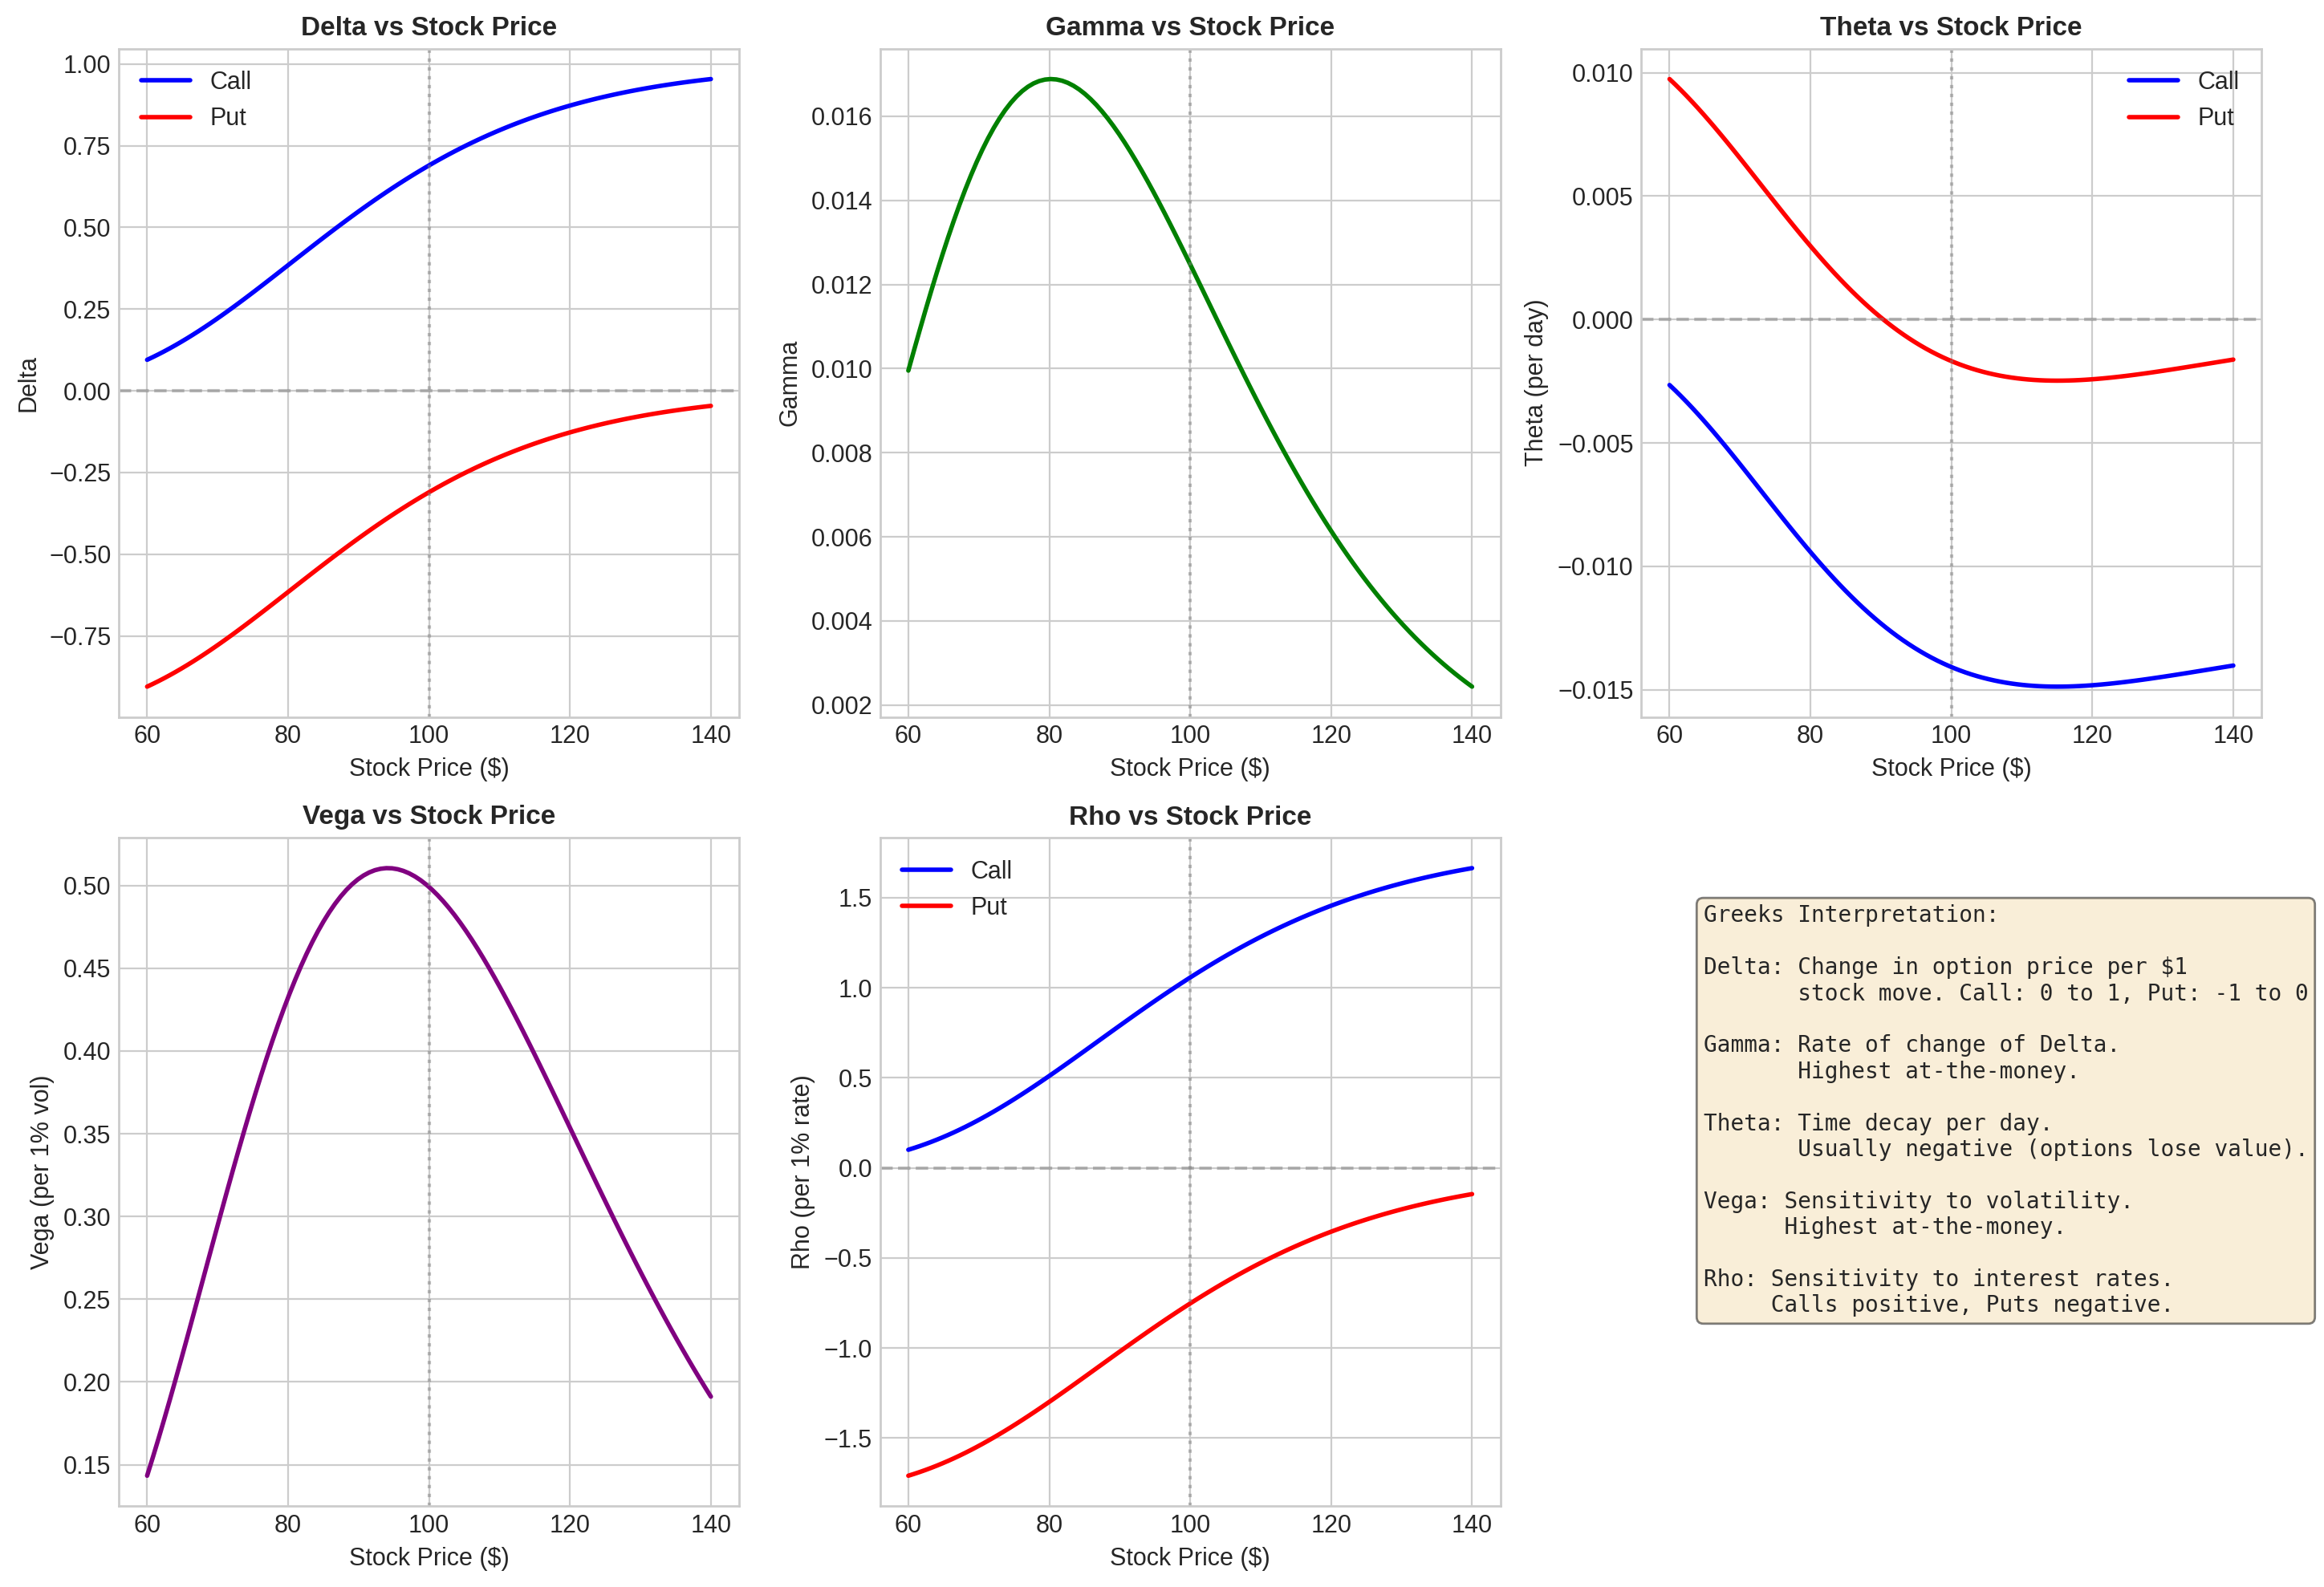

Plot saved: options_pricing_greeks.png


In [5]:
# Visualize Greeks across stock prices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
stock_prices = np.linspace(60, 140, 100)

# Calculate Greeks for each stock price
deltas_call = [calculate_greeks(S, K, T, r, sigma, 'call')['delta'] for S in stock_prices]
deltas_put = [calculate_greeks(S, K, T, r, sigma, 'put')['delta'] for S in stock_prices]
gammas = [calculate_greeks(S, K, T, r, sigma, 'call')['gamma'] for S in stock_prices]
thetas_call = [calculate_greeks(S, K, T, r, sigma, 'call')['theta'] for S in stock_prices]
thetas_put = [calculate_greeks(S, K, T, r, sigma, 'put')['theta'] for S in stock_prices]
vegas = [calculate_greeks(S, K, T, r, sigma, 'call')['vega'] for S in stock_prices]
rhos_call = [calculate_greeks(S, K, T, r, sigma, 'call')['rho'] for S in stock_prices]
rhos_put = [calculate_greeks(S, K, T, r, sigma, 'put')['rho'] for S in stock_prices]

# Delta
axes[0, 0].plot(stock_prices, deltas_call, 'b-', label='Call', linewidth=2)
axes[0, 0].plot(stock_prices, deltas_put, 'r-', label='Put', linewidth=2)
axes[0, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].axvline(x=K, color='gray', linestyle=':', alpha=0.5)
axes[0, 0].set_xlabel('Stock Price ($)')
axes[0, 0].set_ylabel('Delta')
axes[0, 0].set_title('Delta vs Stock Price', fontsize=12, fontweight='bold')
axes[0, 0].legend()

# Gamma
axes[0, 1].plot(stock_prices, gammas, 'g-', linewidth=2)
axes[0, 1].axvline(x=K, color='gray', linestyle=':', alpha=0.5)
axes[0, 1].set_xlabel('Stock Price ($)')
axes[0, 1].set_ylabel('Gamma')
axes[0, 1].set_title('Gamma vs Stock Price', fontsize=12, fontweight='bold')

# Theta
axes[0, 2].plot(stock_prices, thetas_call, 'b-', label='Call', linewidth=2)
axes[0, 2].plot(stock_prices, thetas_put, 'r-', label='Put', linewidth=2)
axes[0, 2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 2].axvline(x=K, color='gray', linestyle=':', alpha=0.5)
axes[0, 2].set_xlabel('Stock Price ($)')
axes[0, 2].set_ylabel('Theta (per day)')
axes[0, 2].set_title('Theta vs Stock Price', fontsize=12, fontweight='bold')
axes[0, 2].legend()

# Vega
axes[1, 0].plot(stock_prices, vegas, 'purple', linewidth=2)
axes[1, 0].axvline(x=K, color='gray', linestyle=':', alpha=0.5)
axes[1, 0].set_xlabel('Stock Price ($)')
axes[1, 0].set_ylabel('Vega (per 1% vol)')
axes[1, 0].set_title('Vega vs Stock Price', fontsize=12, fontweight='bold')

# Rho
axes[1, 1].plot(stock_prices, rhos_call, 'b-', label='Call', linewidth=2)
axes[1, 1].plot(stock_prices, rhos_put, 'r-', label='Put', linewidth=2)
axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].axvline(x=K, color='gray', linestyle=':', alpha=0.5)
axes[1, 1].set_xlabel('Stock Price ($)')
axes[1, 1].set_ylabel('Rho (per 1% rate)')
axes[1, 1].set_title('Rho vs Stock Price', fontsize=12, fontweight='bold')
axes[1, 1].legend()

# Summary table
axes[1, 2].axis('off')
summary_text = """Greeks Interpretation:

Delta: Change in option price per $1 
       stock move. Call: 0 to 1, Put: -1 to 0

Gamma: Rate of change of Delta.
       Highest at-the-money.

Theta: Time decay per day.
       Usually negative (options lose value).

Vega: Sensitivity to volatility.
      Highest at-the-money.

Rho: Sensitivity to interest rates.
     Calls positive, Puts negative."""
axes[1, 2].text(0.1, 0.9, summary_text, transform=axes[1, 2].transAxes,
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('options_pricing_greeks.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved: options_pricing_greeks.png")

## 4. Monte Carlo Option Pricing

Monte Carlo simulation provides a flexible alternative to analytical formulas, especially for:
- Path-dependent options (Asian, Barrier, Lookback)
- Options with multiple underlying assets
- Complex payoff structures

### The Algorithm

1. Simulate many stock price paths using geometric Brownian motion
2. Calculate payoff at expiration for each path
3. Discount average payoff to present value

Stock price evolution:
$$S_T = S_0 \exp\left[(r - \frac{\sigma^2}{2})T + \sigma\sqrt{T}Z\right]$$

where $Z \sim N(0,1)$

In [6]:
def monte_carlo_option(S, K, T, r, sigma, n_simulations=100000, option_type='call', seed=42):
    """
    Price European option using Monte Carlo simulation.
    
    Returns:
    --------
    tuple: (price, std_error, confidence_interval)
    """
    np.random.seed(seed)
    
    # Generate random normal samples
    Z = np.random.standard_normal(n_simulations)
    
    # Simulate terminal stock prices
    ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    
    # Calculate payoffs
    if option_type == 'call':
        payoffs = np.maximum(ST - K, 0)
    else:
        payoffs = np.maximum(K - ST, 0)
    
    # Discount to present value
    discount_factor = np.exp(-r * T)
    discounted_payoffs = discount_factor * payoffs
    
    # Calculate statistics
    price = np.mean(discounted_payoffs)
    std_error = np.std(discounted_payoffs) / np.sqrt(n_simulations)
    ci_lower = price - 1.96 * std_error
    ci_upper = price + 1.96 * std_error
    
    return price, std_error, (ci_lower, ci_upper)

# Compare Monte Carlo vs Black-Scholes
print("Monte Carlo vs Black-Scholes Comparison")
print("=" * 55)

for n_sims in [1000, 10000, 100000, 1000000]:
    mc_call, se_call, ci_call = monte_carlo_option(S0, K, T, r, sigma, n_sims, 'call')
    mc_put, se_put, ci_put = monte_carlo_option(S0, K, T, r, sigma, n_sims, 'put')
    
    print(f"\nSimulations: {n_sims:,}")
    print(f"  Call: MC=${mc_call:.4f} (SE={se_call:.4f}) vs BS=${call_price:.4f}")
    print(f"  Put:  MC=${mc_put:.4f} (SE={se_put:.4f}) vs BS=${put_price:.4f}")
    print(f"  Call Error: {abs(mc_call - call_price):.4f}")

Monte Carlo vs Black-Scholes Comparison

Simulations: 1,000
  Call: MC=$16.2445 (SE=0.7263) vs BS=$10.4506
  Put:  MC=$6.3059 (SE=0.3175) vs BS=$5.5735
  Call Error: 5.7940

Simulations: 10,000
  Call: MC=$16.1279 (SE=0.2264) vs BS=$10.4506
  Put:  MC=$6.6433 (SE=0.1062) vs BS=$5.5735
  Call Error: 5.6773

Simulations: 100,000
  Call: MC=$16.1620 (SE=0.0713) vs BS=$10.4506
  Put:  MC=$6.6121 (SE=0.0335) vs BS=$5.5735
  Call Error: 5.7114

Simulations: 1,000,000
  Call: MC=$16.1007 (SE=0.0225) vs BS=$10.4506
  Put:  MC=$6.6289 (SE=0.0106) vs BS=$5.5735
  Call Error: 5.6501


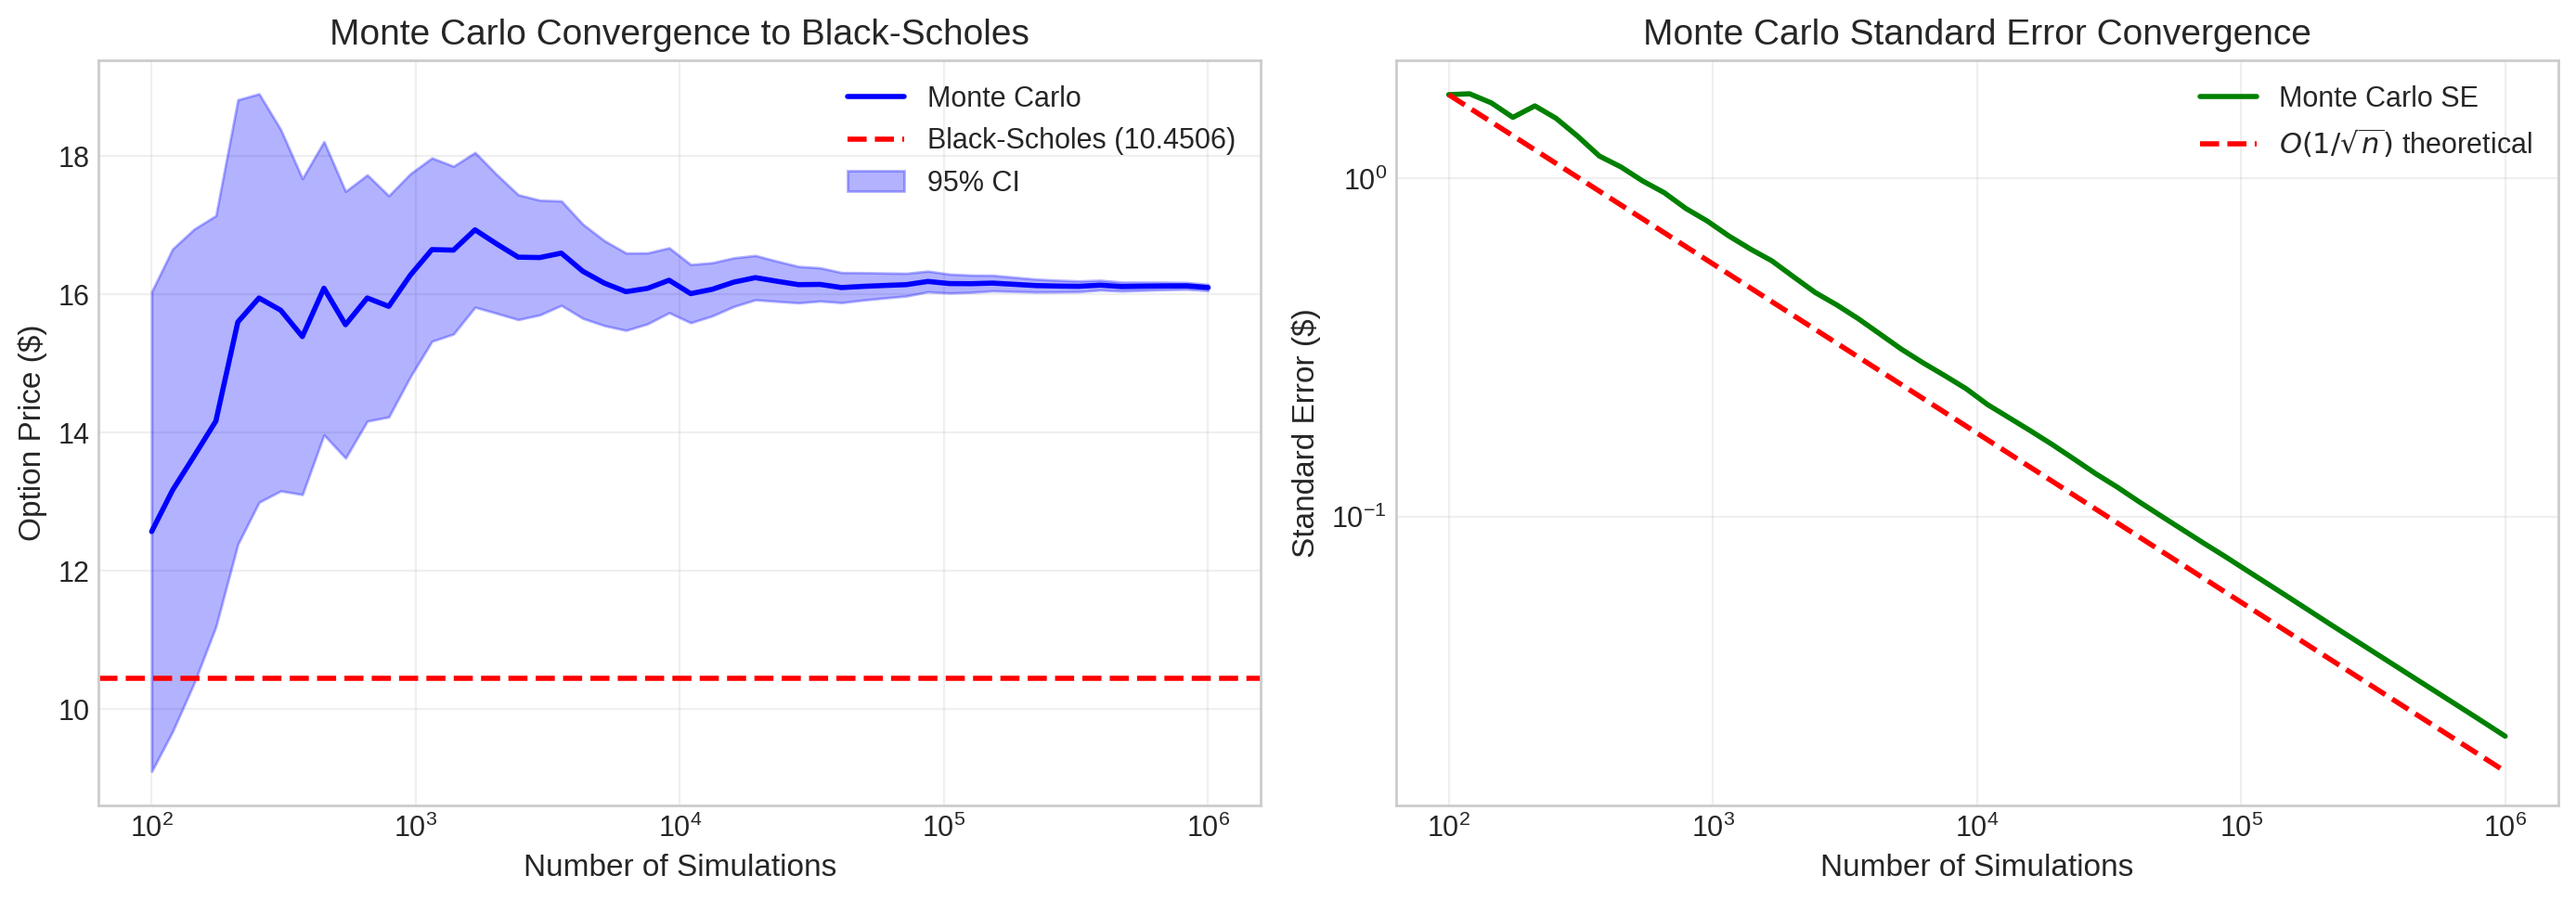

Plot saved: options_pricing_monte_carlo_convergence.png


In [7]:
# Visualize convergence of Monte Carlo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convergence plot
simulation_counts = np.logspace(2, 6, 50).astype(int)
mc_prices = []
mc_errors = []

for n in simulation_counts:
    price, se, _ = monte_carlo_option(S0, K, T, r, sigma, n, 'call')
    mc_prices.append(price)
    mc_errors.append(se)

ax1 = axes[0]
ax1.semilogx(simulation_counts, mc_prices, 'b-', linewidth=2, label='Monte Carlo')
ax1.axhline(y=call_price, color='r', linestyle='--', linewidth=2, label=f'Black-Scholes ({call_price:.4f})')
ax1.fill_between(simulation_counts, 
                  np.array(mc_prices) - 1.96*np.array(mc_errors),
                  np.array(mc_prices) + 1.96*np.array(mc_errors),
                  alpha=0.3, color='blue', label='95% CI')
ax1.set_xlabel('Number of Simulations', fontsize=12)
ax1.set_ylabel('Option Price ($)', fontsize=12)
ax1.set_title('Monte Carlo Convergence to Black-Scholes', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Standard error vs simulations
ax2 = axes[1]
ax2.loglog(simulation_counts, mc_errors, 'g-', linewidth=2, label='Monte Carlo SE')
# Theoretical 1/sqrt(n) convergence
theoretical_se = mc_errors[0] * np.sqrt(simulation_counts[0]) / np.sqrt(simulation_counts)
ax2.loglog(simulation_counts, theoretical_se, 'r--', linewidth=2, label=r'$O(1/\sqrt{n})$ theoretical')
ax2.set_xlabel('Number of Simulations', fontsize=12)
ax2.set_ylabel('Standard Error ($)', fontsize=12)
ax2.set_title('Monte Carlo Standard Error Convergence', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('options_pricing_monte_carlo_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved: options_pricing_monte_carlo_convergence.png")

## 5. Implied Volatility

Implied volatility is the volatility that, when input into Black-Scholes, yields the market price of the option. It represents the market's expectation of future volatility.

We find it by solving: $BS(S, K, T, r, \sigma_{impl}) = \text{Market Price}$

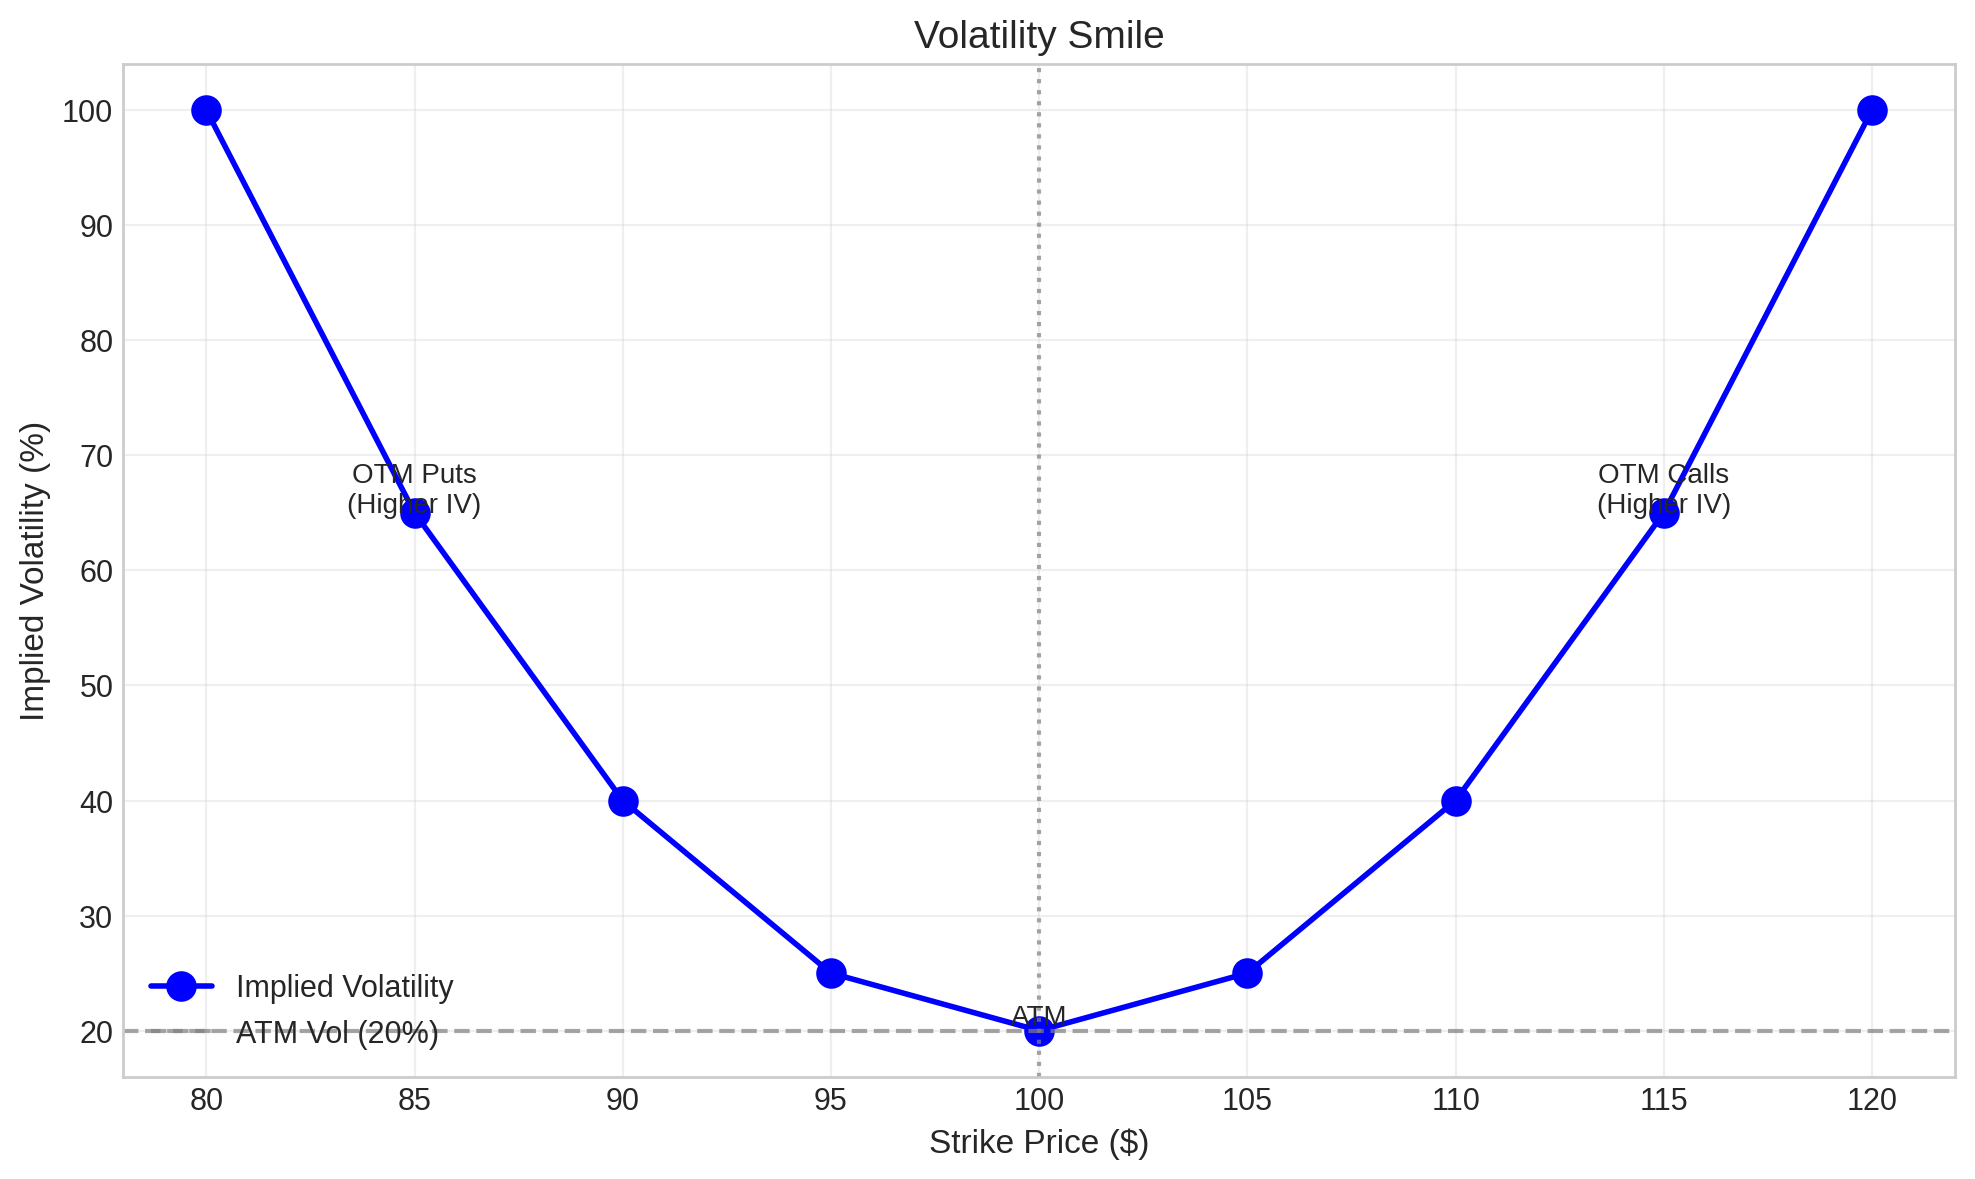

Plot saved: options_pricing_volatility_smile.png


In [8]:
from scipy.optimize import brentq

def implied_volatility(market_price, S, K, T, r, option_type='call'):
    """
    Calculate implied volatility using Brent's method.
    """
    def objective(sigma):
        return black_scholes(S, K, T, r, sigma, option_type) - market_price
    
    try:
        impl_vol = brentq(objective, 0.001, 5.0)
        return impl_vol
    except ValueError:
        return np.nan

# Create volatility smile data
strikes = np.linspace(80, 120, 9)
# Simulated market prices with volatility smile
true_vols = 0.20 + 0.002 * (strikes - 100)**2  # Parabolic smile
market_prices = [black_scholes(S0, K, T, r, vol, 'call') for K, vol in zip(strikes, true_vols)]

# Calculate implied vols
impl_vols = [implied_volatility(price, S0, K, T, r, 'call') for price, K in zip(market_prices, strikes)]

# Plot volatility smile
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(strikes, np.array(impl_vols)*100, 'bo-', markersize=10, linewidth=2, label='Implied Volatility')
ax.axhline(y=20, color='gray', linestyle='--', alpha=0.7, label='ATM Vol (20%)')
ax.axvline(x=100, color='gray', linestyle=':', alpha=0.7)

ax.set_xlabel('Strike Price ($)', fontsize=12)
ax.set_ylabel('Implied Volatility (%)', fontsize=12)
ax.set_title('Volatility Smile', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Add annotations
ax.annotate('OTM Puts\n(Higher IV)', xy=(85, impl_vols[1]*100), fontsize=10, ha='center')
ax.annotate('ATM', xy=(100, impl_vols[4]*100+0.5), fontsize=10, ha='center')
ax.annotate('OTM Calls\n(Higher IV)', xy=(115, impl_vols[7]*100), fontsize=10, ha='center')

plt.tight_layout()
plt.savefig('options_pricing_volatility_smile.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved: options_pricing_volatility_smile.png")

## 6. Summary

### Key Takeaways

1. **Black-Scholes Model**
   - Analytical solution for European options
   - Assumes constant volatility and log-normal returns
   - Fast and deterministic

2. **Monte Carlo Method**
   - Flexible for complex options
   - Convergence rate: $O(1/\sqrt{n})$
   - Can handle path-dependent payoffs

3. **The Greeks**
   - Essential for risk management
   - Delta hedging is most common strategy
   - Gamma, Theta, Vega highest ATM

4. **Implied Volatility**
   - Market's forward-looking expectation
   - Volatility smile violates BS assumptions
   - Key input for options trading

### Further Exploration
- American options (early exercise)
- Exotic options (barriers, Asians, lookbacks)
- Stochastic volatility models (Heston)
- Jump-diffusion models (Merton)

In [9]:
# Final summary
print("Options Pricing Summary")
print("=" * 50)
print(f"\nInput Parameters:")
print(f"  Stock Price: ${S0}")
print(f"  Strike Price: ${K}")
print(f"  Time to Expiry: {T} year")
print(f"  Risk-free Rate: {r*100}%")
print(f"  Volatility: {sigma*100}%")

print(f"\nBlack-Scholes Prices:")
print(f"  Call: ${call_price:.4f}")
print(f"  Put: ${put_price:.4f}")

mc_call_final, _, ci = monte_carlo_option(S0, K, T, r, sigma, 1000000, 'call')
print(f"\nMonte Carlo (1M sims):")
print(f"  Call: ${mc_call_final:.4f} (95% CI: {ci[0]:.4f} to {ci[1]:.4f})")

print(f"\nKey Greeks (ATM Call):")
print(f"  Delta: {call_greeks['delta']:.4f} (shares to hedge)")
print(f"  Gamma: {call_greeks['gamma']:.4f} (delta change per $1)")
print(f"  Theta: ${call_greeks['theta']:.4f}/day (time decay)")
print(f"  Vega: ${call_greeks['vega']:.4f} per 1% vol change")

Options Pricing Summary

Input Parameters:
  Stock Price: $100
  Strike Price: $100
  Time to Expiry: 2.0 year
  Risk-free Rate: 5.0%
  Volatility: 20.0%

Black-Scholes Prices:
  Call: $10.4506
  Put: $5.5735

Monte Carlo (1M sims):
  Call: $16.1007 (95% CI: 16.0566 to 16.1448)

Key Greeks (ATM Call):
  Delta: 0.6897 (shares to hedge)
  Gamma: 0.0125 (delta change per $1)
  Theta: $-0.0141/day (time decay)
  Vega: $0.4991 per 1% vol change
